# Transformer Encoder (Transformer) - 20 Newsgroups Classification

This project implements a compact Transformer encoder for multi-class text classification on the 20 Newsgroups dataset. The model replaces recurrent sequence processing with self-attention, positional embeddings, residual connections, layer normalization, and a feed-forward network. Integer token sequences are used as model inputs to keep preprocessing and inference memory-efficient.

## 1. Import Required Libraries

Import the libraries required for dataset loading, text preprocessing, model development, visualization and evaluation.

In [1]:
import os
import logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Layer, LayerNormalization, MultiHeadAttention, TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW

tf.get_logger().setLevel(logging.ERROR)
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load the 20 Newsgroups Dataset

Load the standard 20 Newsgroups train and test splits and create a stratified validation split from the training data.

In [2]:
newsgroups_train = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)
newsgroups_test = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes"),
    shuffle=False
)

train_texts = np.array(newsgroups_train.data, dtype=object)
train_labels = np.array(newsgroups_train.target, dtype=np.int32)
test_texts = np.array(newsgroups_test.data, dtype=object)
test_labels = np.array(newsgroups_test.target, dtype=np.int32)
class_names = newsgroups_train.target_names

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.10, random_state=42, stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))
print("Number of Classes:", len(class_names))

Training Samples: 10182
Validation Samples: 1132
Test Samples: 7532
Number of Classes: 20


## 3. Explore the Dataset

Inspect class distribution, approximate document lengths, and representative documents before vectorization.

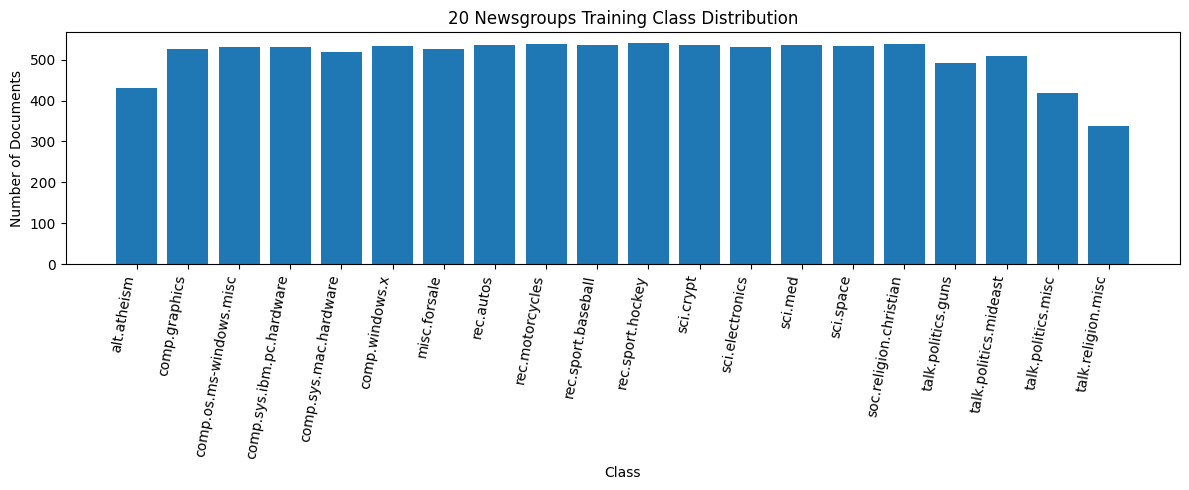

Class: alt.atheism

Actually, the story goes that Lucifer refused to bow before MAN as 
God commanded him to.  Lucifer was devoted to God.

Oh yeah, there is nothing in Genesis that says the snake was anything
more than a snake (well, a talking one...had legs at the time, too).

I don't think pointing out contradictions in STORIES is the best way
to show the error in theology:  if they think a supernatural entity
kicked the first humans out of paradise because they bit into a
fruit that gave them special powers...well, they might not respond
well to reason and logic.  :^)

Class: comp.graphics
Has anybody made a converter from irit's .irt or .dat format to
 .pov format ?

Thanks!


Class: comp.os.ms-windows.misc
Hi all,

I have a DLL in which I Register a class and create a window of that
class type.  Both calls require a module instance handle, hInstance.

Petzold's 3.1 book says that it is best to use the module instance
handle of the calling program, not the module instance handle o

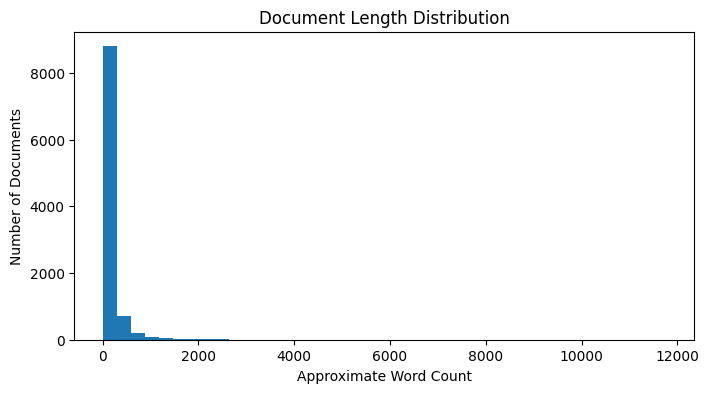

In [3]:
classes, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(12,5))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Documents")
plt.title("20 Newsgroups Training Class Distribution")
plt.xticks(classes, class_names, rotation=80, ha="right")
plt.tight_layout()
plt.show()

for label in range(min(4, len(class_names))):
    idx = np.where(train_labels == label)[0][0]
    print("="*100)
    print("Class:", class_names[label])
    print(train_texts[idx][:700])
    print()

sample_lengths = [len(text.split()) for text in train_texts[:10000]]
plt.figure(figsize=(8,4))
plt.hist(sample_lengths, bins=40)
plt.xlabel("Approximate Word Count")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.show()

## 4. Preprocess the Text

Build the vocabulary from the training documents and convert every split into fixed-length integer token sequences.

In [4]:
max_tokens = 20000
sequence_length = 256

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        train_texts
    ).batch(256)
)

vocabulary_size = len(
    vectorizer.get_vocabulary()
)

x_train = vectorizer(
    tf.constant(train_texts)
).numpy().astype(np.int32)

x_val = vectorizer(
    tf.constant(val_texts)
).numpy().astype(np.int32)

x_test = vectorizer(
    tf.constant(test_texts)
).numpy().astype(np.int32)

print("Vocabulary Size:", vocabulary_size)
print("Sequence Length:", sequence_length)
print("Training Token Shape:", x_train.shape)
print("Validation Token Shape:", x_val.shape)
print("Test Token Shape:", x_test.shape)

Vocabulary Size: 20000
Sequence Length: 256
Training Token Shape: (10182, 256)
Validation Token Shape: (1132, 256)
Test Token Shape: (7532, 256)


## 5. Create TensorFlow Input Pipelines

Create integer-token datasets for mini-batch training and evaluation so that text conversion is not repeated during every step.

In [5]:
batch_size = 32

train_data = tf.data.Dataset.from_tensor_slices(
    (x_train, train_labels)
).shuffle(
    buffer_size=len(x_train),
    seed=42,
    reshuffle_each_iteration=True
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

val_data = tf.data.Dataset.from_tensor_slices(
    (x_val, val_labels)
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

test_data = tf.data.Dataset.from_tensor_slices(
    (x_test, test_labels)
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

print("Batch Size:", batch_size)

Batch Size: 32


## 6. Build the Transformer Encoder

Construct token and positional embeddings followed by two Transformer encoder blocks. Each block uses multi-head self-attention, residual connections, layer normalization, and a feed-forward network. Padding-aware attention and masked global pooling are used so padded positions do not contribute to the learned document representation.

In [6]:
embedding_dim = 128
num_heads = 4
ff_dim = 256
dropout_rate = 0.20


class TokenAndPositionEmbedding(Layer):
    def __init__(
        self,
        vocab_size,
        seq_len,
        dim,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.token_embedding = Embedding(
            input_dim=vocab_size,
            output_dim=dim
        )

        self.position_embedding = Embedding(
            input_dim=seq_len,
            output_dim=dim
        )

        self.seq_len = seq_len

    def call(self, inputs):
        positions = tf.range(
            start=0,
            limit=self.seq_len,
            delta=1
        )

        token_embeddings = self.token_embedding(inputs)
        position_embeddings = self.position_embedding(positions)

        return token_embeddings + position_embeddings


class MaskedGlobalAveragePooling(Layer):
    def call(self, inputs):
        tokens, mask = inputs

        mask = tf.cast(
            tf.keras.ops.expand_dims(
                mask,
                axis=-1
            ),
            tokens.dtype
        )

        summed = tf.reduce_sum(
            tokens * mask,
            axis=1
        )

        counts = tf.reduce_sum(
            mask,
            axis=1
        )

        return summed / tf.maximum(
            counts,
            tf.keras.backend.epsilon()
        )


class TransformerEncoder(Layer):
    def __init__(
        self,
        dim,
        heads,
        ff_dim,
        dropout=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.attention = MultiHeadAttention(
            num_heads=heads,
            key_dim=dim // heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            Dense(
                ff_dim,
                activation="gelu"
            ),
            Dropout(dropout),
            Dense(dim)
        ])

        self.norm1 = LayerNormalization(
            epsilon=1e-6
        )

        self.norm2 = LayerNormalization(
            epsilon=1e-6
        )

        self.dropout1 = Dropout(dropout)
        self.dropout2 = Dropout(dropout)

    def call(
        self,
        inputs,
        attention_mask=None,
        training=False
    ):
        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=attention_mask,
            training=training
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        x = self.norm1(
            inputs + attention_output
        )

        feed_forward_output = self.ffn(
            x,
            training=training
        )

        feed_forward_output = self.dropout2(
            feed_forward_output,
            training=training
        )

        return self.norm2(
            x + feed_forward_output
        )


token_input = Input(
    shape=(sequence_length,),
    dtype=tf.int32,
    name="token_input"
)

padding_mask = tf.keras.ops.not_equal(
    token_input,
    0
)

attention_mask = tf.keras.ops.logical_and(
    tf.keras.ops.expand_dims(
        padding_mask,
        axis=1
    ),
    tf.keras.ops.expand_dims(
        padding_mask,
        axis=2
    )
)

x = TokenAndPositionEmbedding(
    vocabulary_size,
    sequence_length,
    embedding_dim,
    name="token_position_embedding"
)(token_input)

# Transformer Encoder Block 1
x = TransformerEncoder(
    embedding_dim,
    num_heads,
    ff_dim,
    dropout_rate,
    name="transformer_encoder_1"
)(
    x,
    attention_mask=attention_mask
)

# Transformer Encoder Block 2
x = TransformerEncoder(
    embedding_dim,
    num_heads,
    ff_dim,
    dropout_rate,
    name="transformer_encoder_2"
)(
    x,
    attention_mask=attention_mask
)

x = MaskedGlobalAveragePooling()(
    [
        x,
        padding_mask
    ]
)

x = Dropout(
    dropout_rate
)(x)

x = Dense(
    128,
    activation="gelu"
)(x)

x = Dropout(
    dropout_rate
)(x)

output = Dense(
    len(class_names),
    activation="softmax",
    name="classifier"
)(x)

transformer_model = Model(
    inputs=token_input,
    outputs=output,
    name="20Newsgroups_Transformer_Classifier"
)

transformer_model.compile(
    optimizer=AdamW(
        learning_rate=3e-4,
        weight_decay=5e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transformer_model.summary()

Model: "20Newsgroups_Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_input         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 256)       │          0 │ token_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 1, 256)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 256, 1)    │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_position_emb… │ (None, 256, 128)  │  2,592,768 │ token_input[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_and         │ (None, 256, 256)  │          0 │ expand_dims[0][0… │
│ (LogicalAnd)        │                   │            │ expand_dims_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 256, 128)  │    132,480 │ token_position_e… │
│ (TransformerEncode… │                   │            │ logical_and[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 256, 128)  │    132,480 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ logical_and[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_global_aver… │ (None, 128)       │          0 │ transformer_enco… │
│ (MaskedGlobalAvera… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ masked_global_av… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 20)        │      2,580 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,876,820 (10.97 MB)

 Trainable params: 2,876,820 (10.97 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Transformer

Train the Transformer encoder while monitoring validation accuracy and restore the weights from the epoch with the strongest validation performance. Dropout and AdamW weight decay are used to reduce overfitting and improve generalization.

In [7]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True
)

history = transformer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    shuffle=False,
    callbacks=[early_stopping]
)

best_epoch = int(
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

print("Best Epoch:", best_epoch)
print(
    f"Best Validation Accuracy: "
    f"{history.history['val_accuracy'][best_epoch - 1]:.4f}"
)

print(
    f"Validation Loss at Best Epoch: "
    f"{history.history['val_loss'][best_epoch - 1]:.4f}"
)

Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.1874 - loss: 2.5813 - val_accuracy: 0.4046 - val_loss: 1.8371
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.5497 - loss: 1.3793 - val_accuracy: 0.6184 - val_loss: 1.2480
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7849 - loss: 0.6834 - val_accuracy: 0.6758 - val_loss: 1.1855
Epoch 4/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8902 - loss: 0.3716 - val_accuracy: 0.7041 - val_loss: 1.2826
Epoch 5/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9351 - loss: 0.2259 - val_accuracy: 0.6917 - val_loss: 1.4377
Epoch 6/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9561 - loss: 0.1570 - val_accuracy: 0.7032 - val_loss: 1.6341
Epoch 7/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9637 - loss: 0.1284 - val_accuracy: 0.6970 - val_loss: 1.7422
Best Epoch: 4
Best Validation Accuracy: 0.7041
Validation Loss at Best Epoch: 1.2826


## 8. Training Curves

Visualize training and validation accuracy and loss.

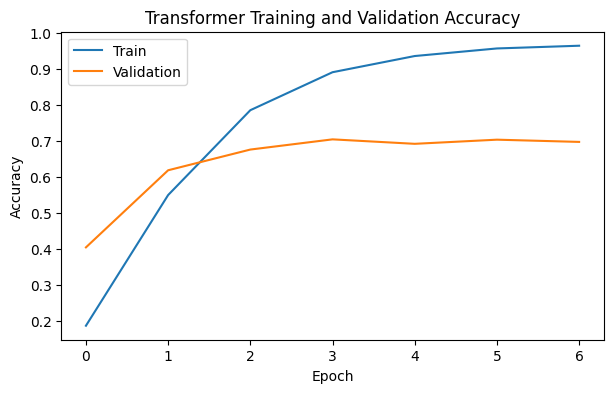

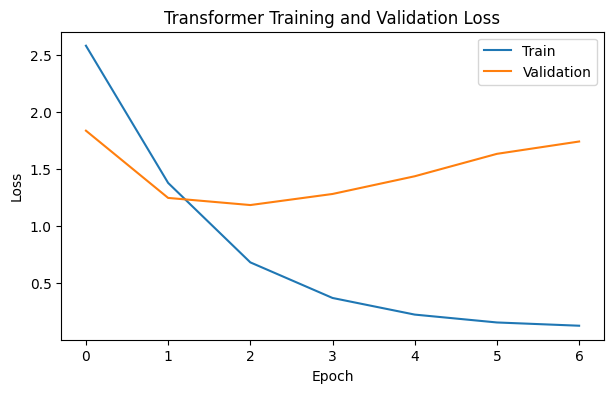

In [8]:
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate the restored best model on the held-out test set using small batches and generate predictions for downstream classification analysis.

In [9]:
test_loss, test_accuracy = transformer_model.evaluate(
    test_data,
    verbose=1
)

probabilities = transformer_model.predict(
    test_data,
    verbose=1
)

predictions = np.argmax(
    probabilities,
    axis=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6241 - loss: 1.7888
236/236 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Test Loss: 1.7888
Test Accuracy: 0.6241


In [13]:
from sklearn.metrics import accuracy_score

class_wise_accuracy = {}

for class_id, class_name in enumerate(class_names):
    class_mask = test_labels == class_id

    class_accuracy = accuracy_score(
        test_labels[class_mask],
        predictions[class_mask]
    )

    class_wise_accuracy[class_name] = class_accuracy

print("Class-wise Accuracy")
print("=" * 60)

for class_name, accuracy in class_wise_accuracy.items():
    print(f"{class_name:<35} {accuracy:.4f} ({accuracy * 100:.2f}%)")

Class-wise Accuracy
alt.atheism                         0.3856 (38.56%)
comp.graphics                       0.6041 (60.41%)
comp.os.ms-windows.misc             0.5457 (54.57%)
comp.sys.ibm.pc.hardware            0.6301 (63.01%)
comp.sys.mac.hardware               0.5974 (59.74%)
comp.windows.x                      0.7063 (70.63%)
misc.forsale                        0.7795 (77.95%)
rec.autos                           0.7475 (74.75%)
rec.motorcycles                     0.5854 (58.54%)
rec.sport.baseball                  0.7103 (71.03%)
rec.sport.hockey                    0.8571 (85.71%)
sci.crypt                           0.6843 (68.43%)
sci.electronics                     0.4758 (47.58%)
sci.med                             0.6389 (63.89%)
sci.space                           0.6599 (65.99%)
soc.religion.christian              0.6533 (65.33%)
talk.politics.guns                  0.6346 (63.46%)
talk.politics.mideast               0.6622 (66.22%)
talk.politics.misc                  0.4452 (

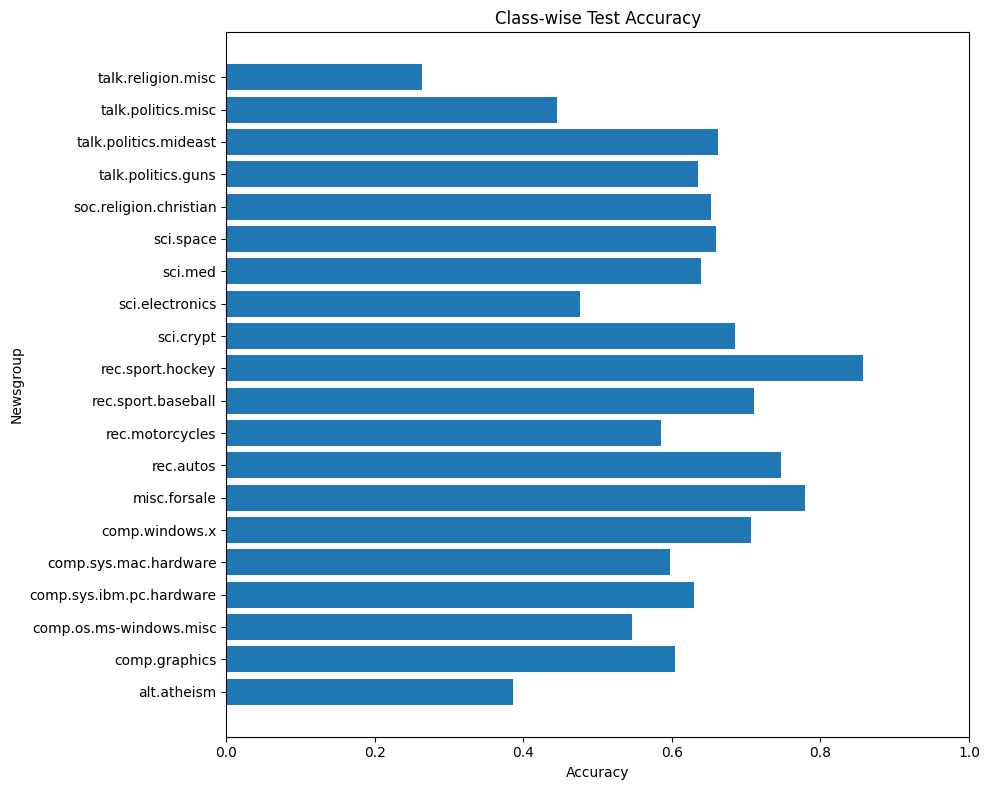

In [14]:
plt.figure(figsize=(10, 8))

plt.barh(
    list(class_wise_accuracy.keys()),
    list(class_wise_accuracy.values())
)

plt.xlabel("Accuracy")
plt.ylabel("Newsgroup")
plt.title("Class-wise Test Accuracy")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

## 10. Classification Report

Measure precision, recall and F1-score across all twenty categories.

In [10]:
print(classification_report(
    test_labels,
    predictions,
    target_names=class_names,
    digits=4
))

                          precision    recall  f1-score   support

             alt.atheism     0.4489    0.3856    0.4148       319
           comp.graphics     0.6456    0.6041    0.6242       389
 comp.os.ms-windows.misc     0.6143    0.5457    0.5780       394
comp.sys.ibm.pc.hardware     0.5798    0.6301    0.6039       392
   comp.sys.mac.hardware     0.7541    0.5974    0.6667       385
          comp.windows.x     0.6327    0.7063    0.6675       395
            misc.forsale     0.6909    0.7795    0.7325       390
               rec.autos     0.4199    0.7475    0.5377       396
         rec.motorcycles     0.7590    0.5854    0.6610       398
      rec.sport.baseball     0.8812    0.7103    0.7866       397
        rec.sport.hockey     0.8593    0.8571    0.8582       399
               sci.crypt     0.7549    0.6843    0.7179       396
         sci.electronics     0.4908    0.4758    0.4832       393
                 sci.med     0.7047    0.6389    0.6702       396
         

## 11. Confusion Matrix

Visualize class-level prediction errors.

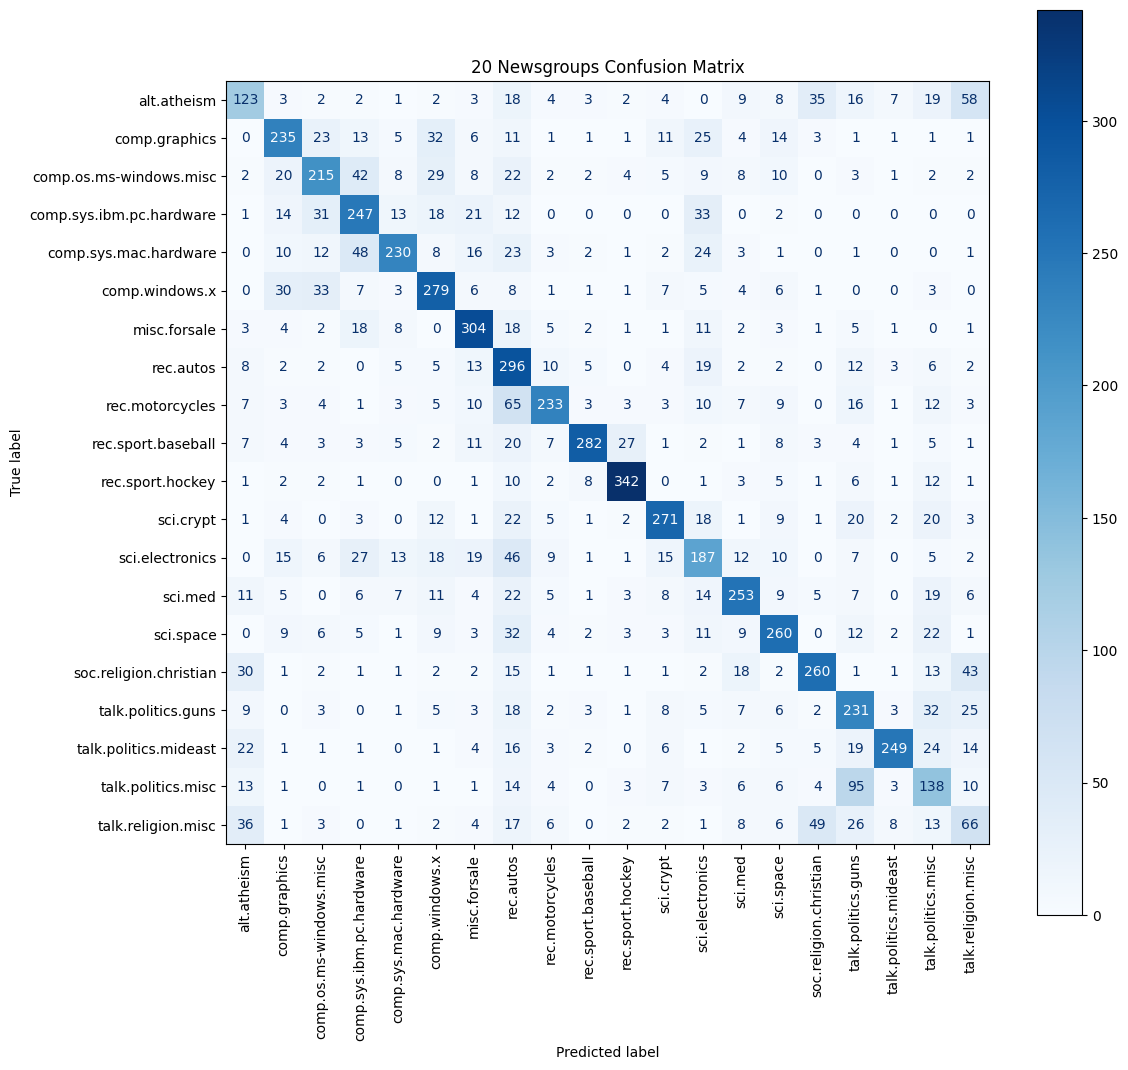

In [11]:
cm = confusion_matrix(test_labels, predictions)
fig, ax = plt.subplots(figsize=(12,11))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format="d")
plt.title("20 Newsgroups Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Inspect representative misclassified documents.

In [12]:
misclassified = np.where(predictions != test_labels)[0]
for idx in misclassified[:8]:
    print("="*100)
    print("True Label     :", class_names[test_labels[idx]])
    print("Predicted Label:", class_names[predictions[idx]])
    print("Document:")
    print(test_texts[idx][:1200])
    print()

True Label     : sci.space
Predicted Label: comp.graphics
Document:
I'm afraid I was not able to find the GIFs... is the list 
updated weekly, perhaps, or am I just missing something?

True Label     : comp.windows.x
Predicted Label: comp.os.ms-windows.misc
Document:
Just opened up the distribution.


True Label     : comp.os.ms-windows.misc
Predicted Label: comp.windows.x
Document:
[ Lots of stuff deleted because I felt like it ]

This MS bashing has definitely lost all its humor value.

I think most of the people posting are forgetting that most users
of MS products do not even know about internet, and Unix is that
very unfriendly place where bizzare abreviations replace the rather
comfortable abreviations they know. And the abreviations have subtle
differences between the different vendors. While PC users tend to
customize any windowing setup, they can not do much with their 
command line.

So to most of the computer users in the world MS product symbolize
quality. MS has made their

# 13. Key Findings

- The Transformer encoder achieved a **test accuracy of 62.41%** with a **weighted F1-score of 0.6280** and a **macro F1-score of 0.6170** across the 20 Newsgroups test set.
- Validation accuracy increased from **40.46% in Epoch 1** to a maximum of **70.41% at Epoch 4**. After this point, training accuracy continued increasing while validation performance fluctuated and validation loss increased, indicating substantial overfitting.
- The best validation checkpoint was **Epoch 4**, selected using validation accuracy. At this epoch, training accuracy was **89.02%**, compared with **70.41% validation accuracy**, giving a substantial generalization gap.
- Class-level performance varied considerably. The strongest class was **rec.sport.hockey**, with an F1-score of **0.8582**, followed by **rec.sport.baseball** at **0.7866** and **talk.politics.mideast** at **0.7545**.
- The weakest classes were **talk.religion.misc** with an F1-score of **0.2688**, **alt.atheism** at **0.4148**, and **talk.politics.misc** at **0.4207**. These results indicate that the model handled semantically overlapping categories less reliably than categories with more distinctive vocabulary.
- The class-wise accuracy analysis showed a similar pattern. Accuracy was highest for **rec.sport.hockey (85.71%)** and **misc.forsale (77.95%)**, while **talk.religion.misc (26.29%)** and **alt.atheism (38.56%)** were the most difficult classes.
- Error analysis showed several cases involving closely related technical or topical categories. For example, documents from `comp.windows.x` and `comp.os.ms-windows.misc` were confused with one another, while some short or information-poor documents provided limited evidence for reliable classification.
- The Transformer successfully learned meaningful topic-specific representations, but the results also show the limitations of training a relatively small Transformer encoder from scratch on a modest-sized corpus without pretrained language representations.

# 14. Conclusion

The Transformer encoder successfully demonstrated the core components of Transformer-based sequence modelling, including token and positional embeddings, multi-head self-attention, residual connections, layer normalization, feed-forward processing, padding-aware attention, and regularized training.

The final model achieved **62.41% accuracy on the 20 Newsgroups test set**, with a **weighted F1-score of 0.6280**. Validation accuracy reached a higher maximum of **70.41% at Epoch 4**, but the widening gap between training and validation performance showed that the model was overfitting as training continued.

The class-level results showed that performance depended strongly on the category. Topics with distinctive vocabulary, such as sports and for-sale discussions, were classified more reliably, while semantically similar categories involving religion, politics, and related technical subjects produced substantially more errors. This behaviour was also reflected in the confusion matrix and the representative misclassified documents.

Overall, the experiment demonstrates that a Transformer encoder can learn useful representations for multi-class document classification from scratch, while also showing the practical limitations of limited training data, class overlap, and model generalization when no pretrained language representation is used.